In [1]:
import mujoco

import time
import itertools
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

from pathlib import Path
import enum
from tqdm import tqdm

In [2]:
class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

In [3]:
# from robot_descriptions import spot_mj_description
model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm.xml")
model_xml = model_dir / "scene_arm.xml"
# model = mujoco.MjModel.from_xml_path(spot_mj_description.MJCF_PATH)
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

""

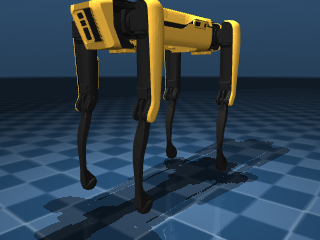

In [4]:
with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

""

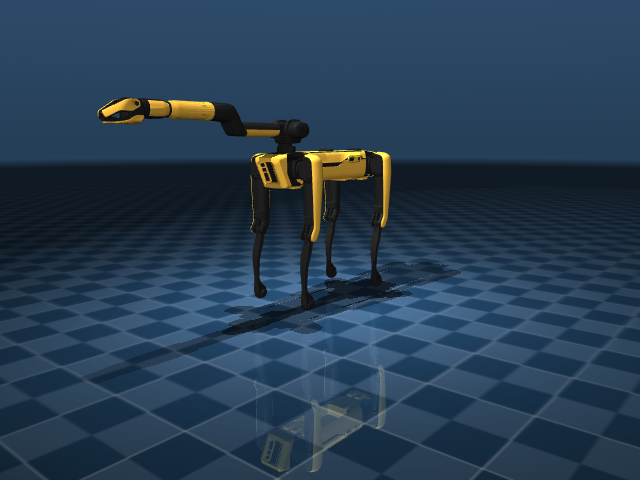

In [5]:
# data.joint('arm_sh0').qpos = np.pi

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 3

renderer = mujoco.Renderer(model, height=h, width=w)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

In [6]:
print(data.joint('arm_sh0'))

<_MjDataJointViews
  cdof: array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  8.80756445e-03, -4.39862107e-04]])
  cdof_dot: array([[0., 0., 0., 0., 0., 0.]])
  id: 13
  name: 'arm_sh0'
  qLDiagInv: array([0.61657631])
  qLDiagSqrtInv: array([0.78522373])
  qacc: array([-1.95123087])
  qacc_smooth: array([-1.95123087])
  qacc_warmstart: array([-1.95123087])
  qfrc_actuator: array([0.])
  qfrc_applied: array([0.])
  qfrc_bias: array([0.])
  qfrc_constraint: array([0.])
  qfrc_inverse: array([0.])
  qfrc_passive: array([0.])
  qfrc_smooth: array([0.])
  qpos: array([0.])
  qvel: array([0.])
  xanchor: array([0.292, 0.   , 0.938])
  xaxis: array([0., 0., 1.])
>


In [14]:
from dataclasses import dataclass
import numpy as np
import mediapy as media
from pathlib import Path
import enum
from tqdm import tqdm
import mujoco

def quartic(t: float) -> float:
  return 0 if abs(t) > 1 else (1 - t**2) ** 2


def blend_coef(t: float, duration: float, std: float) -> float:
  normalised_time = 2 * t / duration - 1
  return quartic(normalised_time / std)


In [22]:
res = Resolution.SD
fps = 30
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.05

np.random.seed(12345)

# Rendering options for visual and collision geoms.
vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

camera.distance = 2

frames = []
for i in tqdm(range(nsteps)):
  # data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 2500/2500 [00:01<00:00, 1330.88it/s]


This browser does not support the video tag.


Важно учитывать конфигурацию робота, в которой он находится в момент расчета координат (по результатам симуляции выше) или _(как-то)_ "сбросить" положение звеньев.

In [35]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))

[0.278 0.001 0.618]
[0.278 0.001 0.618]
[-0.061  0.001  0.62 ]
[0.338 0.001 0.716]
[0.338 0.001 0.716]
[0.338 0.001 0.716]


In [10]:
# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

frames = []
for i in tqdm(range(nsteps)):
  data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 5000/5000 [00:07<00:00, 688.35it/s]


This browser does not support the video tag.
